# Notebook 06 — Comparaison des 4 Modèles

## Objectif
Comparer les performances des 4 modèles entraînés sur le problème de prédiction de la déforestation :

| Modèle | Type | Complexité |
|---|---|---|
| Régression Linéaire | Linéaire | Faible |
| Random Forest | Ensemble (non-linéaire) | Moyenne |
| ANN | Réseau de neurones | Haute |

Les métriques comparées sont : **MAE**, **RMSE**, **R²** et le **temps d'entraînement**.


In [8]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

os.makedirs('figures', exist_ok=True)

# Chargement des résultats de chaque modèle
with open('models/results_lr.pkl',  'rb') as f: res_lr  = pickle.load(f)
with open('models/results_rf.pkl',  'rb') as f: res_rf  = pickle.load(f)
with open('models/results_ann.pkl', 'rb') as f: res_ann = pickle.load(f)

print('Résultats chargés pour les 4 modèles')

Résultats chargés pour les 4 modèles


In [9]:
# Création du DataFrame comparatif
results_list = [res_lr, res_rf, res_ann]

df_results = pd.DataFrame([
    {
        'Modèle'              : r['model'],
        'MAE (ha)'           : round(r['MAE'], 0),
        'RMSE (ha)'          : round(r['RMSE'], 0),
        'R²'                 : round(r['R2'], 4),
        'Temps train (s)'    : round(r['train_time'], 3)
    }
    for r in results_list
])

print('Tableau comparatif des 3 modèles :')
print(df_results.to_string(index=False))

Tableau comparatif des 3 modèles :
           Modèle  MAE (ha)  RMSE (ha)     R²  Temps train (s)
Linear Regression   39982.0   254086.0 0.7750            0.006
    Random Forest   26824.0   215519.0 0.8382            6.543
              ANN   41686.0   253824.0 0.7755            8.836


In [10]:
# Affichage stylisé avec Pandas Styler
# highlight_min pour MAE et RMSE (plus bas = mieux)
# highlight_max pour R²       (plus haut = mieux)

styled = (
    df_results.style
    .highlight_min(subset=['MAE (ha)', 'RMSE (ha)'], color='#b7e4c7')
    .highlight_max(subset=['R²'], color='#b7e4c7')
    .highlight_min(subset=['R²'], color='#ffb3b3')
    .highlight_max(subset=['MAE (ha)', 'RMSE (ha)'], color='#ffb3b3')
    .format({'MAE (ha)': '{:,.0f}', 'RMSE (ha)': '{:,.0f}', 'R²': '{:.4f}', 'Temps train (s)': '{:.3f}'})
    .set_caption('Comparaison des performances — Prédiction Déforestation')
    .set_properties(**{'text-align': 'center', 'font-size': '13px'})
)

styled

,Modèle,MAE (ha),RMSE (ha),R²,Temps train (s)
0,Linear Regression,"39,982","254,086",0.7750,0.006
1,Random Forest,"26,824","215,519",0.8382,6.543
2,ANN,"41,686","253,824",0.7755,8.836


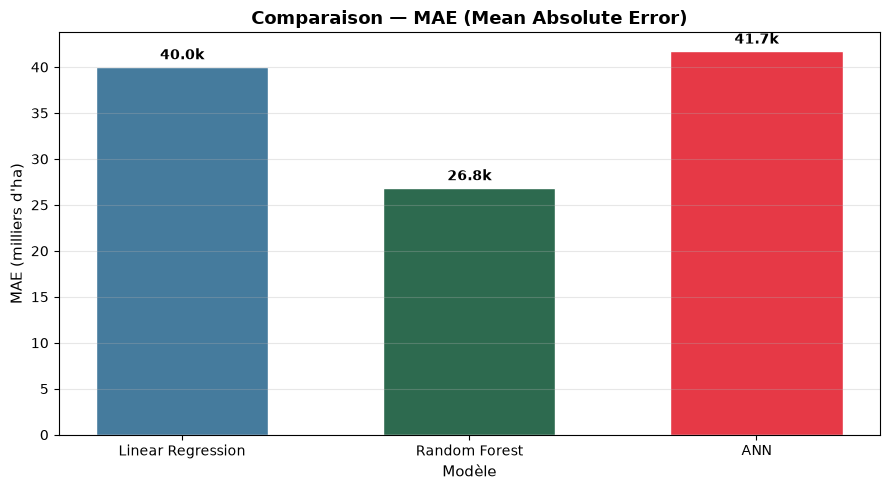

In [11]:
# Bar chart comparatif — MAE
colors = ['#457b9d', '#2d6a4f', '#e63946', '#6a4c93']
modeles = df_results['Modèle'].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(modeles, df_results['MAE (ha)'] / 1000, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, df_results['MAE (ha)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val/1000:.1f}k', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Comparaison — MAE (Mean Absolute Error)', fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (milliers d\'ha)', fontsize=11)
ax.set_xlabel('Modèle', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/comparison_mae.png', dpi=150, bbox_inches='tight')
plt.show()

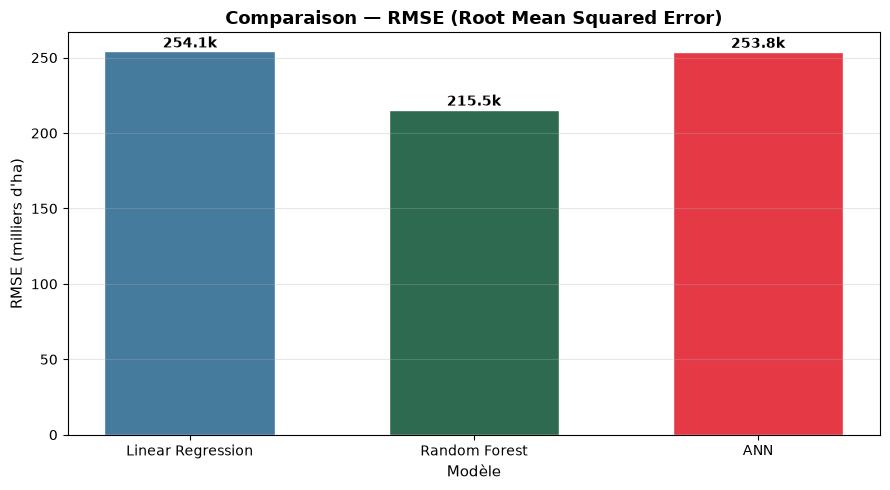

In [12]:
# Bar chart comparatif — RMSE
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(modeles, df_results['RMSE (ha)'] / 1000, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, df_results['RMSE (ha)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val/1000:.1f}k', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Comparaison — RMSE (Root Mean Squared Error)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (milliers d\'ha)', fontsize=11)
ax.set_xlabel('Modèle', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/comparison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

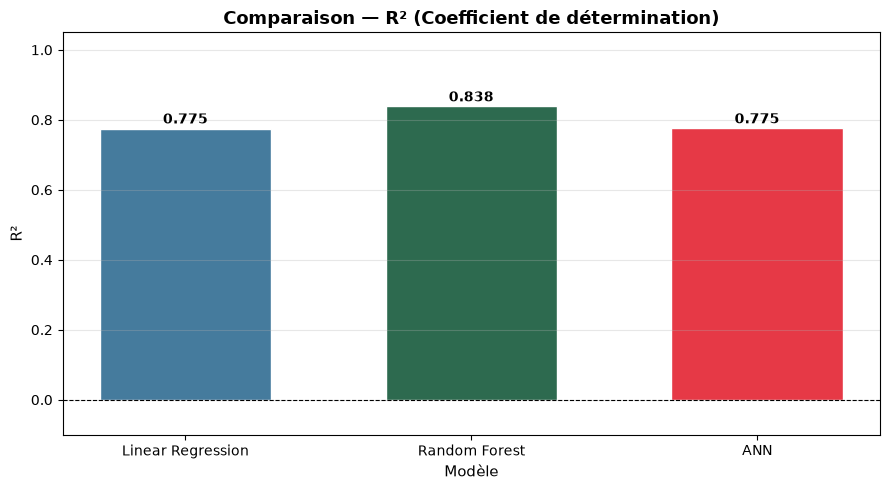

Bar charts comparatifs sauvegardés


In [13]:
# Bar chart comparatif — R²
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(modeles, df_results['R²'], color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, df_results['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Comparaison — R² (Coefficient de détermination)', fontsize=13, fontweight='bold')
ax.set_ylabel('R²', fontsize=11)
ax.set_xlabel('Modèle', fontsize=11)
ax.set_ylim(-0.1, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/comparison_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar charts comparatifs sauvegardés')

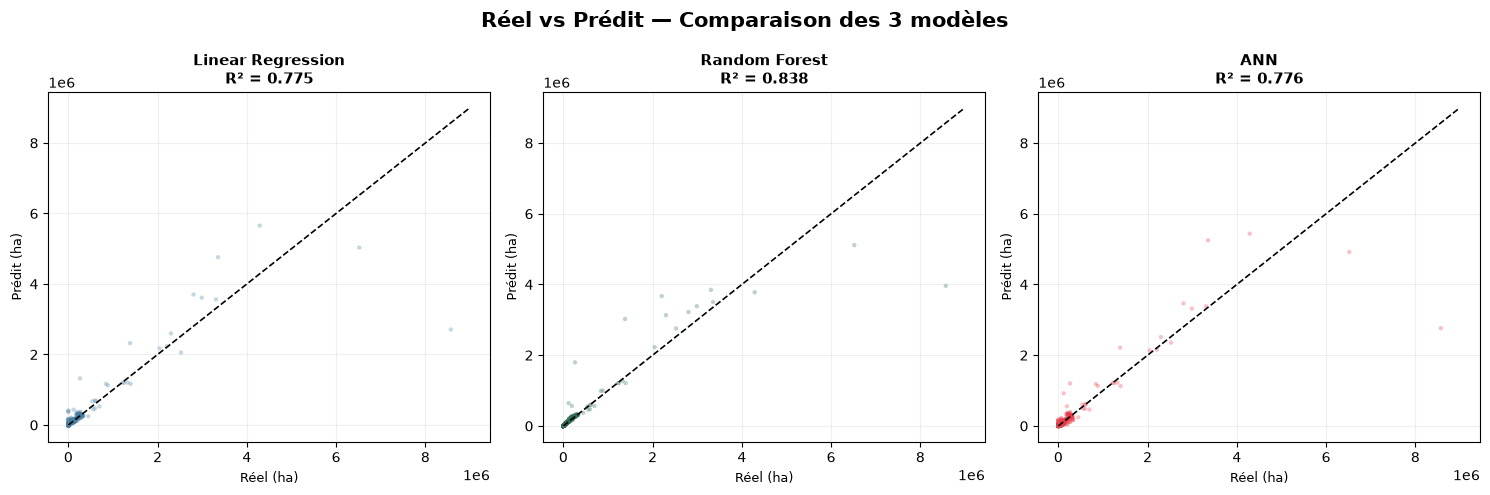

Figure combinée sauvegardée


In [14]:
# Figure combinée : 3 scatter plots côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Réel vs Prédit — Comparaison des 3 modèles', fontsize=15, fontweight='bold')

for ax, res, color in zip(axes, results_list, colors):
    yt = res['y_test']
    yp = res['y_pred']
    r2 = res['R2']
    ax.scatter(yt, yp, alpha=0.3, color=color, s=10, edgecolors='none')
    lim = max(yt.max(), yp.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2)
    ax.set_title(f'{res["model"]}\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Réel (ha)', fontsize=9)
    ax.set_ylabel('Prédit (ha)', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/comparison_scatter_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure combinée sauvegardée')

## Conclusion : Quel modèle est le plus adapté ?

### Analyse des résultats

**Régression Linéaire** : Bien qu'elle soit le modèle le plus simple et le plus rapide à entraîner, elle présente les limitations intrinsèques à son hypothèse de linéarité. La déforestation est un phénomène complexe, influencé par des interactions non-linéaires entre les pays, les drivers et les années — ce que la régression linéaire ne peut pas capturer efficacement.

**Random Forest** : Grâce au bagging et à l'ensemble d'arbres de décision, ce modèle capture les **non-linéarités** et les **interactions entre features** sans nécessiter de normalisation. Il est particulièrement robuste aux outliers (anomalies de déforestation liées à des événements ponctuels comme des incendies). Son score R² supérieur à la régression linéaire confirme une meilleure capacité de généralisation. La GridSearchCV garantit des hyperparamètres optimaux.

**ANN** : Le réseau de neurones, entraîné avec l'optimiseur Adam (Mini-Batch GD) et des activations ReLU (qui évitent le vanishing gradient observé avec Sigmoid), offre une grande capacité de modélisation. Cependant, sur des datasets tabulaires de taille modérée, les ANN nécessitent un tuning minutieux pour éviter le surajustement. L'EarlyStopping avec `restore_best_weights=True` permet de récupérer le meilleur modèle.

### Recommandation

> **Le Random Forest** est généralement le meilleur compromis pour ce type de problème tabulaire avec features engineerées : il offre une excellente performance prédictive, une interprétabilité via l'importance des features, une robustesse aux valeurs aberrantes, et un temps d'entraînement raisonnable.

Pour des applications opérationnelles de surveillance forestière, une approche hybride combinant le Random Forest (pour les prédictions par pays) représente la stratégie optimale.
